Método do Cotovelo

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from kneed import KneeLocator
from sklearn.cluster import KMeans


In [22]:
normalizado = pd.read_csv("..\\datasets_paralelos\\spotify_normalizado.csv", encoding='utf-8', low_memory=True)

In [23]:
CLUSTER_FEATURES = [
    'danceability',
    'energy',
    'loudness',
    'speechiness',
    'acousticness',
    'valence',
    'tempo',
    'liveness',
    'instrumentalness'
]

x = normalizado[CLUSTER_FEATURES]


In [24]:
qtd = len(CLUSTER_FEATURES)
nome = f'cotovelo_padronizado{qtd}features'

In [26]:
wcss = {}
for k in range(2, 15):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(x[CLUSTER_FEATURES])
    wcss[k] = kmeans.inertia_

In [27]:
kneedle = KneeLocator(
    x=list(wcss.keys()),
    y=list(wcss.values()),
    curve='convex',
    direction='decreasing'
)
optimal_k = kneedle.elbow

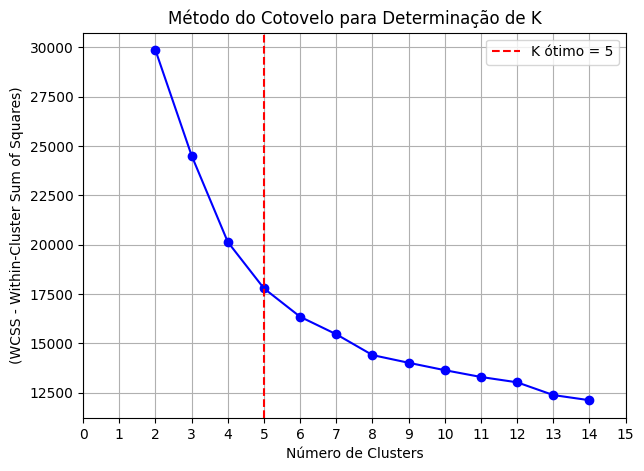

In [30]:
plt.figure(figsize=(7,5))
plt.plot(list(wcss.keys()), list(wcss.values()), 'bo-')
plt.axvline(x=optimal_k, color='r', linestyle='--', label=f'K ótimo = {optimal_k}')
plt.xlabel('Número de Clusters')
plt.xticks(range(0,16))
plt.ylabel('(WCSS - Within-Cluster Sum of Squares)')
plt.title('Método do Cotovelo para Determinação de K')
plt.legend()
plt.grid(True)
plt.savefig(f"..\\clustering_outputs\\cotovelo.png", dpi=300, bbox_inches='tight')
plt.show()

